# Pipeline Proyecto Mapper - Análisis Topológico

Esta libreta construye un pipeline limpio para: cargar los datos, convertir SMILES a grafos, calcular una medida de similitud WL, generar la matriz de similitud y derivar la matriz de distancias.

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import plotly.express as px
from collections import Counter
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, rdchem
import umap.umap_ as umap

## 1. Cargar datos

Se carga el archivo `NPASSv2.0_structureInfo.txt`, se eliminan valores faltantes y se muestrea un subconjunto para que el cálculo de la matriz sea manejable.

In [55]:
DATA_PATH = "folders/laboratorios/laboratorio_2/NPASSv2.0_structureInfo.txt"
npass = pd.read_csv(DATA_PATH, sep='	', na_values='n.a.')
npass = npass.dropna(subset=['SMILES']).reset_index(drop=True)

subset = npass.sample(1000, random_state=42).reset_index(drop=True)
print('Total registros cargados:', len(npass))
print('Registros usados en el subconjunto:', len(subset))

Total registros cargados: 96235
Registros usados en el subconjunto: 1000


## 2. Convertir SMILES a grafos y calcular etiquetas WL

Se define un pipeline sencillo que convierte cada SMILES en un grafo de RDKit y luego calcula las etiquetas de Weisfeiler-Lehman usando los tipos de enlace.

In [56]:
BOND_MAP = {
    'SINGLE': 1, 'DOUBLE': 2, 'TRIPLE': 3, 'AROMATIC': 12,
    'QUADRUPLE': 4, 'QUINTUPLE': 5, 'HEXTUPLE': 6,
    'ONEANDAHALF': 7, 'TWOANDAHALF': 8, 'THREEANDAHALF': 9,
    'FOURANDAHALF': 10, 'FIVEANDAHALF': 11, 'IONIC': 13,
    'HYDROGEN': 14, 'THREECENTER': 15, 'DATIVEONE': 16,
    'DATIVE': 17, 'DATIVEL': 18, 'DATIVER': 19, 'OTHER': 20,
    'UNSPECIFIED': 0, 'ZERO': 21
}

def smiles_to_graph(smile):
    mol = Chem.MolFromSmiles(smile)
    if mol is None:
        return None
    G = nx.Graph()
    for atom in mol.GetAtoms():
        G.add_node(atom.GetIdx(), atomic_num=atom.GetAtomicNum(), is_aromatic=atom.GetIsAromatic(), atom_symbol=atom.GetSymbol())
    for bond in mol.GetBonds():
        G.add_edge(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx(), bond_type=bond.GetBondType())
    return G

def initial_node_label(G, v):
    a = G.nodes[v]
    return f"{a['atomic_num']}{'A' if a.get('is_aromatic') else ''}"

def bond_label(edge_data):
    bt = edge_data.get('bond_type')
    name = getattr(bt, 'name', str(bt))
    return BOND_MAP.get(name, BOND_MAP['OTHER'])

def wl_con_edges(G, labels):
    new_labels = {}
    for v in G.nodes():
        neigh_sig = []
        for u in G.neighbors(v):
            edge_code = bond_label(G[v][u])
            neigh_sig.append((edge_code, labels[u]))
        neigh_sig.sort()
        new_labels[v] = (labels[v], tuple(neigh_sig))
    return new_labels

def wl_labels(G, h=2):
    labels = {v: initial_node_label(G, v) for v in G.nodes()}
    all_levels = [list(labels.values())]
    for _ in range(h):
        labels = wl_con_edges(G, labels)
        all_levels.append(list(labels.values()))
    return all_levels

def wl_vector(G, h=2):
    labels_by_level = wl_labels(G, h=h)
    fp = Counter()
    for level in labels_by_level:
        fp.update(level)
    return fp

def tanimoto_count(fp1, fp2):
    if not fp1 and not fp2:
        return 1.0
    keys = set(fp1) | set(fp2)
    dot = sum(fp1.get(k, 0) * fp2.get(k, 0) for k in keys)
    norm1 = sum(v*v for v in fp1.values())
    norm2 = sum(v*v for v in fp2.values())
    denom = norm1 + norm2 - dot
    return 0.0 if denom == 0 else float(dot / denom)

def wl_tanimoto(G1, G2, h=2):
    fp1 = wl_vector(G1, h=h)
    fp2 = wl_vector(G2, h=h)
    return tanimoto_count(fp1, fp2)

In [57]:
subset['Graph'] = subset['SMILES'].apply(smiles_to_graph)
subset = subset.dropna(subset=['Graph']).reset_index(drop=True)
print('Grafos válidos en el subconjunto:', len(subset))

[23:13:04] Explicit valence for atom # 20 N, 4, is greater than permitted


Grafos válidos en el subconjunto: 999


## 3. Generar la matriz de similitud y la matriz de distancias

Se calcula la matriz de similitud WL y luego se transforma en una matriz de distancia como `1 - similitud`.

In [ ]:
n = len(subset)
similarity_matrix = np.zeros((n, n), dtype=float)
for i in range(n):
    g1 = subset.loc[i, 'Graph']
    for j in range(i, n):
        g2 = subset.loc[j, 'Graph']
        similarity = wl_tanimoto(g1, g2, h=2)
        similarity_matrix[i, j] = similarity
        similarity_matrix[j, i] = similarity

print('Matriz de similitud generada con forma:', similarity_matrix.shape)
distance_matrix = 1.0 - similarity_matrix
print('Matriz de distancias generada con forma:', distance_matrix.shape)

In [34]:
pd.DataFrame(similarity_matrix).to_csv('matriz_similitud_wl.csv', index=False)
pd.DataFrame(distance_matrix).to_csv('matriz_distancias_wl.csv', index=False)
print('Archivos guardados: matriz_similitud_wl.csv, matriz_distancias_wl.csv')

Archivos guardados: matriz_similitud_wl.csv, matriz_distancias_wl.csv


In [58]:
similarity_matrix = pd.read_csv('matriz_similitud_wl.csv').values
distance_matrix = pd.read_csv('matriz_distancias_wl.csv').values

In [59]:
print('Matriz de similitud cargada con forma:', similarity_matrix.shape)
print('Matriz de distancias cargada con forma:', distance_matrix.shape)
print('Rango de similitud:', similarity_matrix.min(), 'a', similarity_matrix.max())
print('Rango de distancias:', distance_matrix.min(), 'a', distance_matrix.max())

Matriz de similitud cargada con forma: (999, 999)
Matriz de distancias cargada con forma: (999, 999)
Rango de similitud: 0.0 a 1.0
Rango de distancias: 0.0 a 1.0


In [60]:
print(distance_matrix)

[[0.         0.53580247 0.68255188 ... 0.59382423 0.49737303 0.69787857]
 [0.53580247 0.         0.38339921 ... 0.73931933 0.48528302 0.40381471]
 [0.68255188 0.38339921 0.         ... 0.78550725 0.30983464 0.01936376]
 ...
 [0.59382423 0.73931933 0.78550725 ... 0.         0.54092527 0.79529737]
 [0.49737303 0.48528302 0.30983464 ... 0.54092527 0.         0.32387312]
 [0.69787857 0.40381471 0.01936376 ... 0.79529737 0.32387312 0.        ]]


## 4. Visualización UMAP

Se usa la matriz de distancia precomputada para proyectar los compuestos en 2D y se muestra una visualización interactiva con Plotly.

In [61]:
def molecular_descriptors(smile):
    mol = Chem.MolFromSmiles(smile)
    if mol is None:
        return pd.Series({'MolWt': np.nan, 'NumAtoms': np.nan, 'NumRings': np.nan})
    return pd.Series({
        'MolWt': Descriptors.MolWt(mol),
        'NumAtoms': mol.GetNumAtoms(),
        'NumRings': rdMolDescriptors.CalcNumRings(mol),
    })

descriptor_df = subset['SMILES'].apply(molecular_descriptors)
subset = pd.concat([subset, descriptor_df], axis=1)

embedding = umap.UMAP(n_components=2, metric='precomputed', random_state=42).fit_transform(distance_matrix)
umap_df = subset[['SMILES', 'MolWt', 'NumAtoms', 'NumRings']].copy()
umap_df['UMAP 1'] = embedding[:, 0]
umap_df['UMAP 2'] = embedding[:, 1]

fig = px.scatter(
    umap_df,
    x='UMAP 1',
    y='UMAP 2',
    color='MolWt',
    hover_data={'SMILES': True, 'MolWt': ':.2f', 'NumAtoms': True, 'NumRings': True},
    color_continuous_scale='Viridis',
    title='UMAP sobre matriz de distancias WL coloreado por peso molecular',
)
fig.update_traces(marker=dict(size=7, opacity=0.8))
fig.update_layout(template='plotly_white')
fig.show()

c:\Users\narro\miniconda3\Lib\site-packages\umap\umap_.py:1865: UserWarning:

using precomputed metric; inverse_transform will be unavailable

c:\Users\narro\miniconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [62]:
fig = px.scatter(
    umap_df,
    x='UMAP 1',
    y='UMAP 2',
    color='NumAtoms',
    hover_data={'SMILES': True, 'MolWt': ':.2f', 'NumAtoms': True, 'NumRings': True},
    color_continuous_scale='Viridis',
    title='UMAP sobre matriz de distancias WL coloreado por peso molecular',
)
fig.update_traces(marker=dict(size=7, opacity=0.8))
fig.update_layout(template='plotly_white')
fig.show()

In [63]:
fig = px.scatter(
    umap_df,
    x='UMAP 1',
    y='UMAP 2',
    color='NumRings',
    hover_data={'SMILES': True, 'MolWt': ':.2f', 'NumAtoms': True, 'NumRings': True},
    color_continuous_scale='Viridis',
    title='UMAP sobre matriz de distancias WL coloreado por peso molecular',
)
fig.update_traces(marker=dict(size=7, opacity=0.8))
fig.update_layout(template='plotly_white')
fig.show()

## 5. Aplicar filtro de excentricidad 
Implementamos el algoritmo Mapper usando excentricidad como filtro. Los pasos son:

1. Calcular excentricidad media $f(i) = \\frac{1}{n} \\sum_j D[i, j]$ para cada punto $i$.
2. Dividir el rango de f en intervalos solapados.
3. Para cada intervalo, filtrar puntos y hacer clustering.
4. Cada cluster es un nodo; aristas conectan clusters que comparten puntos de intervalos solapados.

In [64]:
# Calcular excentricidad (filtro)
eccentricity = np.mean(distance_matrix, axis=1)
print('Rango de excentricidad:', eccentricity.min(), 'a', eccentricity.max())


Rango de excentricidad: 0.4483664819348416 a 0.998998998998999


In [65]:
# historiograma de excentricidad
px.histogram(
    x=eccentricity,
    nbins=30,
    labels={'x': 'Excentricidad', 'y': 'Frecuencia'},
    title='Distribución de la excentricidad',
    template='plotly_white'
).show()


In [66]:

# Definir intervalos: dividir en 5 bins con solapamiento de 10%
num_intervals = 5
overlap = 0.1
min_ecc, max_ecc = eccentricity.min(), eccentricity.max()
interval_width = (max_ecc - min_ecc) / num_intervals
overlap_width = interval_width * overlap

intervals = []
for i in range(num_intervals):
    start = min_ecc + i * interval_width * (1 - overlap)
    end = start + interval_width * (1 + overlap)
    if end > max_ecc:
        end = max_ecc
    intervals.append((start, end))

print('Intervalos definidos:', intervals)

Intervalos definidos: [(np.float64(0.4483664819348416), np.float64(0.5695056356889563)), (np.float64(0.5474803350063899), np.float64(0.6686194887605046)), (np.float64(0.6465941880779382), np.float64(0.7677333418320529)), (np.float64(0.7457080411494867), np.float64(0.8668471949036014)), (np.float64(0.844821894221035), np.float64(0.9659610479751497))]


In [67]:
from sklearn.cluster import AgglomerativeClustering

In [68]:
# Clustering por intervalo
clusters_per_interval = []
for idx, (start, end) in enumerate(intervals):
    # Filtrar puntos en este intervalo
    mask = (eccentricity >= start) & (eccentricity <= end)
    points_in_interval = np.where(mask)[0]
    if len(points_in_interval) == 0:
        clusters_per_interval.append([])
        continue
    
    # Usar submatriz de distancias para clustering
    sub_distances = distance_matrix[np.ix_(points_in_interval, points_in_interval)]
    
    # AgglomerativeClustering con distancias precomputadas, k=3 (ajustable)
    n_clusters = min(3, len(points_in_interval))
    if n_clusters > 1:
        clusterer = AgglomerativeClustering(n_clusters=n_clusters, metric='precomputed', linkage='average')
        labels = clusterer.fit_predict(sub_distances)
    else:
        labels = np.zeros(len(points_in_interval), dtype=int)  # Todos en un cluster si solo 1 punto
    
    # Guardar clusters: lista de listas de índices globales
    clusters = [points_in_interval[labels == c] for c in range(n_clusters)]
    clusters_per_interval.append(clusters)

print('Clusters por intervalo:', [len(cl) for cl in clusters_per_interval])

Clusters por intervalo: [3, 3, 3, 3, 3]


In [69]:
# Construir grafo Mapper
mapper_graph = nx.Graph()

# Nodos: cada cluster es un nodo
node_id = 0
cluster_to_node = {}
for interval_idx, clusters in enumerate(clusters_per_interval):
    for cluster in clusters:
        mapper_graph.add_node(node_id, interval=interval_idx, points=cluster)
        cluster_to_node[(interval_idx, tuple(cluster))] = node_id
        node_id += 1

# Aristas: conectar clusters de intervalos consecutivos si comparten puntos
for i in range(len(intervals) - 1):
    clusters_i = clusters_per_interval[i]
    clusters_j = clusters_per_interval[i + 1]
    for cl_i in clusters_i:
        for cl_j in clusters_j:
            if set(cl_i) & set(cl_j):  # Comparten puntos
                node_i = cluster_to_node[(i, tuple(cl_i))]
                node_j = cluster_to_node[(i + 1, tuple(cl_j))]
                mapper_graph.add_edge(node_i, node_j)

print('Grafo Mapper construido con', mapper_graph.number_of_nodes(), 'nodos y', mapper_graph.number_of_edges(), 'aristas')

Grafo Mapper construido con 15 nodos y 16 aristas


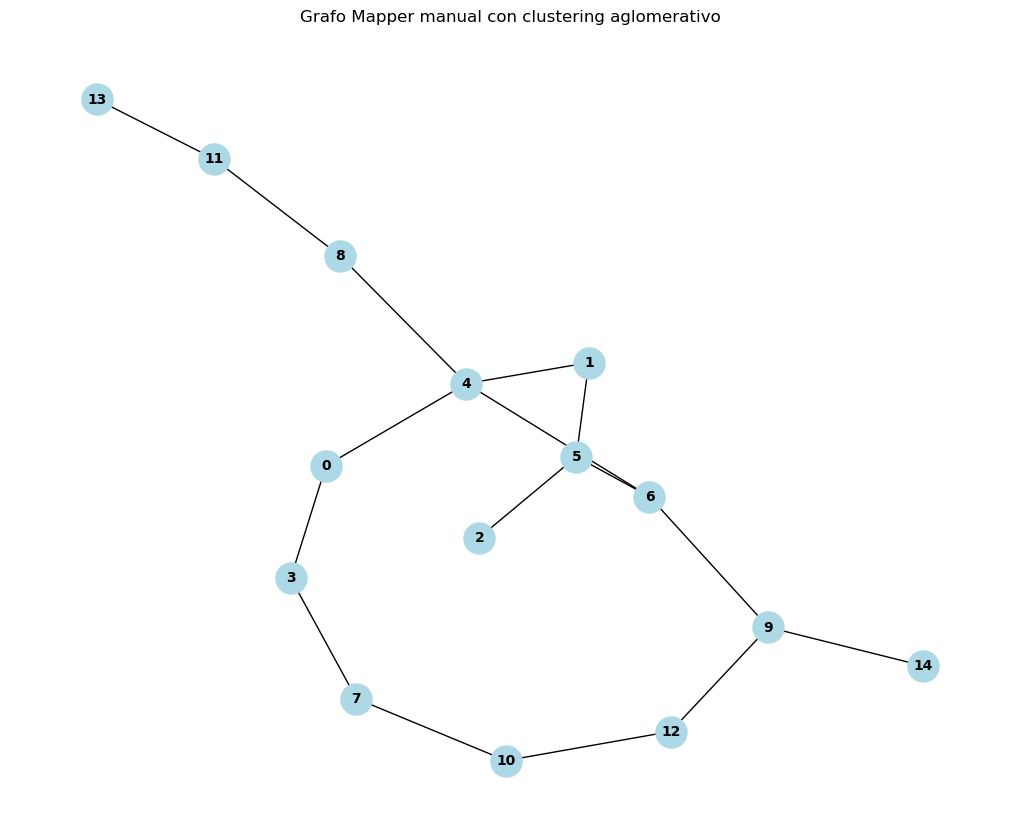

In [70]:
# Visualizar grafo Mapper
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(mapper_graph, seed=42)
nx.draw(mapper_graph, pos, with_labels=True, node_color='lightblue', node_size=500, font_size=10, font_weight='bold')
plt.title('Grafo Mapper manual con clustering aglomerativo')
plt.show()

## 5.1. Segunda versión manual con DBSCAN

Esta variante conserva la misma función filtro y la misma cubierta, pero cambia el clustering interno por DBSCAN para comparar la estabilidad topológica del resultado.

In [71]:
from sklearn.cluster import DBSCAN

dbscan_eps = 0.35
dbscan_min_samples = 3

clusters_per_interval_dbscan = []
for idx, (start, end) in enumerate(intervals):
    mask = (eccentricity >= start) & (eccentricity <= end)
    points_in_interval = np.where(mask)[0]
    if len(points_in_interval) == 0:
        clusters_per_interval_dbscan.append([])
        continue

    sub_distances = distance_matrix[np.ix_(points_in_interval, points_in_interval)]
    labels = DBSCAN(eps=dbscan_eps, min_samples=dbscan_min_samples, metric='precomputed').fit_predict(sub_distances)

    valid_labels = [label for label in np.unique(labels) if label != -1]
    clusters = [points_in_interval[labels == label] for label in valid_labels]
    clusters_per_interval_dbscan.append(clusters)

print('Parámetros DBSCAN:', {'eps': dbscan_eps, 'min_samples': dbscan_min_samples})
print('Clusters por intervalo (DBSCAN):', [len(cl) for cl in clusters_per_interval_dbscan])

Parámetros DBSCAN: {'eps': 0.35, 'min_samples': 3}
Clusters por intervalo (DBSCAN): [1, 1, 3, 4, 1]


In [72]:
mapper_graph_dbscan = nx.Graph()

node_id = 0
cluster_to_node_dbscan = {}
for interval_idx, clusters in enumerate(clusters_per_interval_dbscan):
    for cluster in clusters:
        mapper_graph_dbscan.add_node(node_id, interval=interval_idx, points=cluster)
        cluster_to_node_dbscan[(interval_idx, tuple(cluster))] = node_id
        node_id += 1

for i in range(len(intervals) - 1):
    clusters_i = clusters_per_interval_dbscan[i]
    clusters_j = clusters_per_interval_dbscan[i + 1]
    for cl_i in clusters_i:
        for cl_j in clusters_j:
            if set(cl_i) & set(cl_j):
                node_i = cluster_to_node_dbscan[(i, tuple(cl_i))]
                node_j = cluster_to_node_dbscan[(i + 1, tuple(cl_j))]
                mapper_graph_dbscan.add_edge(node_i, node_j)

components_dbscan = nx.number_connected_components(mapper_graph_dbscan) if mapper_graph_dbscan.number_of_nodes() > 0 else 0
print('Grafo Mapper manual con DBSCAN:', mapper_graph_dbscan.number_of_nodes(), 'nodos,', mapper_graph_dbscan.number_of_edges(), 'aristas y', components_dbscan, 'componentes')

Grafo Mapper manual con DBSCAN: 10 nodos, 6 aristas y 4 componentes


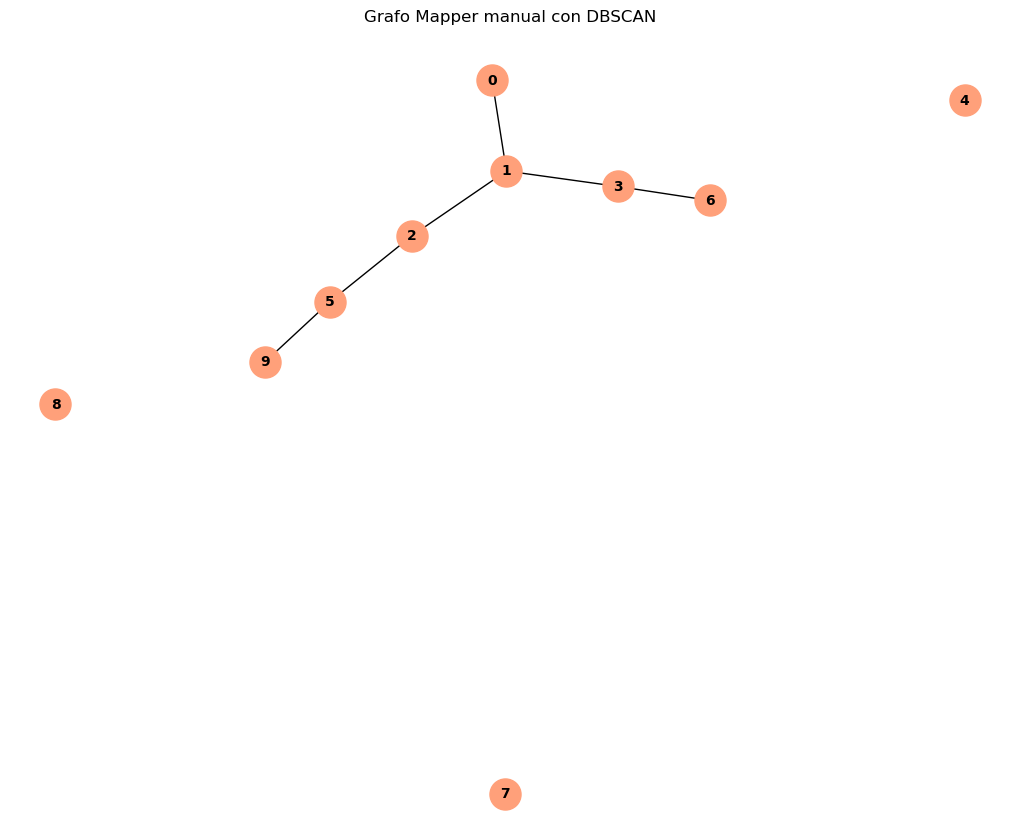

,version,nodes,edges,components
0,Manual + Agglomerative,15,16,1
1,Manual + DBSCAN,10,6,4


In [73]:
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(mapper_graph_dbscan, seed=42)
nx.draw(mapper_graph_dbscan, pos, with_labels=True, node_color='lightsalmon', node_size=500, font_size=10, font_weight='bold')
plt.title('Grafo Mapper manual con DBSCAN')
plt.show()

comparison_df = pd.DataFrame([
    {
        'version': 'Manual + Agglomerative',
        'nodes': mapper_graph.number_of_nodes(),
        'edges': mapper_graph.number_of_edges(),
        'components': nx.number_connected_components(mapper_graph) if mapper_graph.number_of_nodes() > 0 else 0,
    },
    {
        'version': 'Manual + DBSCAN',
        'nodes': mapper_graph_dbscan.number_of_nodes(),
        'edges': mapper_graph_dbscan.number_of_edges(),
        'components': nx.number_connected_components(mapper_graph_dbscan) if mapper_graph_dbscan.number_of_nodes() > 0 else 0,
    },
])

comparison_df

## 6. KeplerMapper (`kmapper`)

Estas celdas reutilizan el filtro de excentricidad calculado arriba y exportan una visualización interactiva en HTML. Si `kmapper` no está instalado, primero ejecuta `pip install kmapper` en tu entorno.

In [74]:
import kmapper as km



In [75]:
from sklearn.cluster import DBSCAN

lens_kmapper = eccentricity.reshape(-1, 1)
projected_X = embedding
tooltip_values = subset['SMILES'].to_numpy()

mapper = km.KeplerMapper(verbose=1)
graph_kmapper = mapper.map(
    lens=lens_kmapper,
    X=projected_X,
    cover=km.Cover(n_cubes=5, perc_overlap=0.1),
    clusterer=DBSCAN(eps=0.5, min_samples=3),
)

html_path = 'mapper_excentricidad_kmapper.html'
mapper.visualize(
    graph_kmapper,
    path_html=html_path,
    title='KeplerMapper con filtro de excentricidad',
    custom_tooltips=tooltip_values,
)


KeplerMapper(verbose=1)
Mapping on data shaped (999, 2) using lens shaped (999, 1)

Creating 5 hypercubes.



Created 22 edges and 35 nodes in 0:00:00.021939.
Wrote visualization to: mapper_excentricidad_kmapper.html


'<!DOCTYPE html>\n<html>\n\n<head>\n  <meta charset="utf-8">\n  <meta name="generator" content="KeplerMapper">\n  <title>KeplerMapper con filtro de excentricidad | KeplerMapper</title>\n\n  <link rel="icon" type="image/png" href="http://i.imgur.com/axOG6GJ.jpg" />\n\n  <link href=\'https://fonts.googleapis.com/css?family=Roboto+Mono:700,300\' rel=\'stylesheet\' type=\'text/css\'>\n  <style>* {\n  margin: 0;\n  padding: 0;\n}\n\nhtml, body {\n  height: 100%;\n}\n\nbody {\n  font-family: "Roboto Mono", "Helvetica", sans-serif;\n  font-size: 14px;\n}\n\n#logo {\n  width:  85px;\n  height: 85px;\n}\n\n#display {\n  color: #95A5A6;\n  background: #212121;\n}\n\n#header {\n  background: #111111;\n}\n\n#print {\n  color: #000;\n  background: #FFF;\n}\n\nh1 {\n  font-size: 21px;\n  font-weight: 300;\n  font-weight: 300;\n}\n\nh2 {\n  font-size: 18px;\n  padding-bottom: 20px;\n  font-weight: 300;\n}\n\nh3 {\n  font-size: 14px;\n  font-weight: 700;\n  text-transform: uppercase;\n}\n\nh4 {\n  fon

In [76]:
#view the html in browser
import webbrowser 
webbrowser.open(html_path)



True

In [77]:
node_rows = [
    {
        'node': node,
        'size': len(members),
        'sample_smiles': subset.iloc[members[0]]['SMILES'] if len(members) > 0 else None,
    }
    for node, members in graph_kmapper['nodes'].items()
]

if node_rows:
    node_summary = pd.DataFrame(node_rows).sort_values('size', ascending=False)
else:
    node_summary = pd.DataFrame(columns=['node', 'size', 'sample_smiles'])
    print('KeplerMapper no generó nodos con los parámetros actuales.')

node_summary.head(10)

,node,size,sample_smiles
0,cube0_cluster0,283,CC(C)c1ccc2c(CCC3[C@@](C)(CCC[C@]23C)CN)c1
26,cube2_cluster1,82,c1cc(ccc1CCNC(=O)C1=Cc2cc(c(cc2[C@@H](c2ccc(c(...
14,cube1_cluster4,81,CC1(C)C=Cc2c(ccc3CC(COc23)c2ccc(c(c2O)OC)O)O1
18,cube1_cluster8,57,CC#CC#C/C=C/1\C=C[C@@]2([C@H](C=CO2)OC(=O)C)O1
1,cube0_cluster1,55,CC(CC(=O)/C=C(/C)\[C@]1(C)CC(C2(C)C3=C(C(=O)C[...
10,cube1_cluster0,48,C[C@@H]1[C@H]([C@@H]([C@@H]([C@H](O1)O[C@@H]1[...
15,cube1_cluster5,44,C[C@H]1[C@@H]([C@H]([C@H]([C@@H](O1)O[C@@H]1[C...
3,cube0_cluster3,40,OC[C@H]1CC[C@@H]([C@H]2C(=C[C@@](C2)(C)CO)[C@H...
13,cube1_cluster3,40,C/C=C\c1ccc(cc1)OC(=O)C(C)CC
28,cube2_cluster3,35,C(=O)[C@@H]([C@@H]1[C@H]([C@@H](CO1)O)O)O
